<a href="https://colab.research.google.com/github/ismoil27/deep_vision_mastery/blob/main/computer_vision.ipynb" target="_parent"><img src="https://colab.research.google.com/assets/colab-badge.svg" alt="Open In Colab"/></a>

# Connect to Google Drive

In [1]:
from google.colab import drive
drive.mount("/content/drive")

Mounted at /content/drive


In [2]:
# imports
import os
from torchvision import transforms, datasets
from torch.utils.data import DataLoader

# Dataset Path

In [3]:
data_dir = "/content/drive/MyDrive/DCV"

print(os.listdir(data_dir))

['News', 'Memo', 'ADVE', 'Note', 'Empty_Papers', 'Form', 'Receipts', 'Letter', 'Report', 'Email', 'Scientific', 'Resume']


In [4]:
transform = transforms.Compose([
    transforms.Resize((128, 128)),
    transforms.ToTensor(),
])

# loading datasets
dataset = datasets.ImageFolder(root=data_dir, transform=transform)
print(dataset.classes)

['ADVE', 'Email', 'Empty_Papers', 'Form', 'Letter', 'Memo', 'News', 'Note', 'Receipts', 'Report', 'Resume', 'Scientific']


In [5]:
# Batch
loader = DataLoader(dataset, batch_size=16, shuffle=True)

images, labels = next(iter(loader))

In [6]:
print(images.shape)
print(labels.shape)

torch.Size([16, 3, 128, 128])
torch.Size([16])


# First CNN Model from Scratch

In [7]:
import torch.nn as nn

In [8]:
num_classes = len(dataset.classes)

class CNN(nn.Module):
  def __init__(self):
    super().__init__()

    self.conv = nn.Sequential(
        nn.Conv2d(3, 16, 3, padding=1),
        nn.ReLU(), # Activation function
        nn.MaxPool2d(2), # Pooling layer => 128x128 > 64x64

        nn.Conv2d(16, 32, 3, padding=1),
        nn.ReLU(),
        nn.MaxPool2d(2), # Pooling layer => 64x64 > 32x32
    )
# [32, 32, 32]
    self.fc = nn.Sequential(
        nn.Flatten(),
        nn.Linear(32 * 32 * 32, 64), # 32768
        nn.ReLU(),
        nn.Linear(64, num_classes)
    )


  def forward(self, x):
    x = self.conv(x)
    x = self.fc(x)
    return x


model = CNN()


In [9]:
# Loss function
criterion = nn.CrossEntropyLoss()

In [10]:
# Optimizer
import torch.optim as optim
optimizer = optim.Adam(model.parameters(), lr=0.001)

In [11]:
from torch.utils.data import Subset
import torch
import random

base_dataset = dataset
while hasattr(base_dataset, "dataset"):
    base_dataset = base_dataset.dataset

class_names = base_dataset.classes

In [13]:
subset_size = 100

indices = list(range(len(dataset)))
random.shuffle(indices)

subset_indices = indices[:subset_size]
dataset = Subset(dataset, subset_indices)

loader = DataLoader(dataset, batch_size=16, shuffle=True)

# Device
device = torch.device("cuda" if torch.cuda.is_available() else "cpu")
model = model.to(device)

# Training
epochs = 3

for epoch in range(epochs):
  model.train()
  total_loss = 0

  for images, labels in loader:
    images = images.to(device)
    labels = labels.to(device)

    outputs = model(images)
    loss = criterion(outputs, labels)

    optimizer.zero_grad()
    loss.backward()
    optimizer.step()

    total_loss += loss.item()

  print(f"Epoch: {epoch+1}, Loss: {total_loss:.4f}")


Epoch: 1, Loss: 15.7921
Epoch: 2, Loss: 15.3818
Epoch: 3, Loss: 14.2413


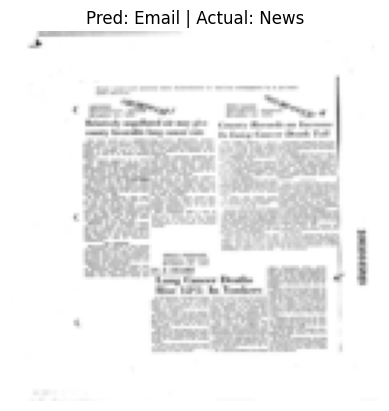

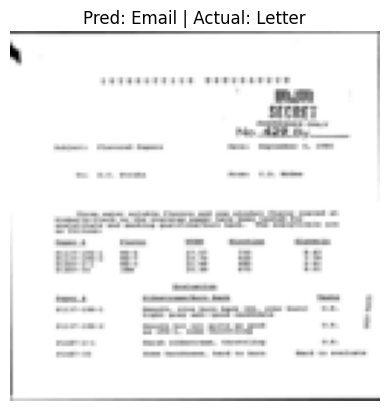

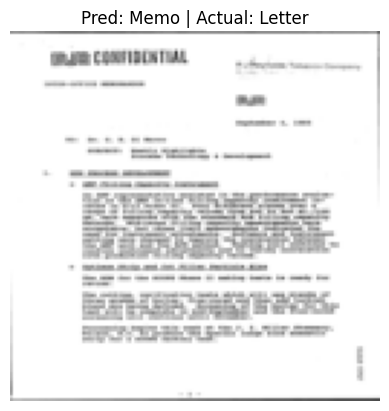

In [16]:
import matplotlib.pyplot as plt

model.eval()

images, labels = next(iter(loader))

images = images.to(device)

with torch.no_grad():
    outputs = model(images)
    _, preds = torch.max(outputs, 1)

# move back to cpu
images = images.cpu()
labels = labels.cpu()
preds = preds.cpu()

for i in range(3):
    img = images[i].permute(1, 2, 0)

    plt.imshow(img)
    plt.title(f"Pred: {class_names[preds[i]]} | Actual: {class_names[labels[i]]}")
    plt.axis('off')
    plt.show()